In [1]:
# Core
import warnings
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt

# Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Training Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import PredefinedSplit

# Training
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# Training Optimization
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Model evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import shap
from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv('Data01.csv')

display(data.iloc[[4888, 3370, 4022, 1408, 911, 4328, 2182, 3010, 4463, 1168]].iloc[:, :20])

# Remove unnecessary columns (per 100 more appropriate)
data = data.drop(['points', 'assists', 'blocks',
       'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'threePointersAttempted', 'threePointersMade', 'freeThrowsAttempted',
       'freeThrowsMade', 'reboundsDefensive', 'reboundsOffensive', 'rebounds',
       'foulsPersonal', 'turnovers', 'plusMinusPoints', 'astTov_per100', 'rebounds_per100', 'stocks',
       'salary', 'cap', 'numMinutesTeam', 'posTeam', 'fieldGoalsMadeTeam'], axis=1)

# Separate the target
X_full = data.drop(columns=['salary_adj'])
y = data[['salary_adj']]

,personId,pName,season,playerteamName,age,GP,height,bodyWeight,win_pct,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,threePointersAttempted,threePointersMade,freeThrowsAttempted,freeThrowsMade
4888,1630208,Nick Richards,2022,Hornets,24,50,84.0,245.0,0.524390,344.00,150.0,13.0,21.0,9.0,90.0,60.0,0.0,0.0,43.0,30.0
3370,201970,Sam Young,2013,Pacers,28,56,78.0,225.0,0.604938,668.00,155.0,42.0,8.0,15.0,148.0,58.0,52.0,16.0,43.0,23.0
4022,203487,Michael Carter-Williams,2018,Hornets,26,52,77.0,190.0,0.439024,810.00,239.0,116.0,23.0,44.0,229.0,76.0,59.0,14.0,89.0,73.0
1408,1894,Corey Maggette,2005,Clippers,25,66,78.0,225.0,0.451220,2413.00,1464.0,225.0,8.0,70.0,986.0,425.0,168.0,51.0,657.0,563.0
911,1495,Tim Duncan,2001,Spurs,25,82,83.0,250.0,0.707317,3136.00,1820.0,245.0,192.0,70.0,1406.0,702.0,27.0,7.0,662.0,409.0
4328,1626158,Richaun Holmes,2025,Wizards,31,31,82.0,235.0,0.219512,528.47,230.0,42.0,23.0,9.0,139.0,90.0,3.0,0.0,60.0,50.0
2182,2571,Leandro Barbosa,2011,Raptors,28,58,75.0,194.0,0.268293,1369.00,769.0,119.0,6.0,50.0,653.0,294.0,213.0,72.0,137.0,109.0
3010,201202,Joel Anthony,2009,Heat,26,65,81.0,245.0,0.524390,1011.00,144.0,27.0,93.0,20.0,118.0,57.0,0.0,0.0,46.0,30.0
4463,1627747,Caris LeVert,2020,Nets,25,45,78.0,205.0,0.486111,1309.00,842.0,199.0,10.0,53.0,732.0,311.0,220.0,80.0,197.0,140.0
1168,1718,Paul Pierce,2009,Celtics,31,81,79.0,235.0,0.756098,2997.00,1658.0,294.0,27.0,80.0,1181.0,540.0,304.0,119.0,553.0,459.0


In [3]:
# Train-Validation-Test split
# Holdout ~5% (~250) instances for testing
# Holdout ~15% subsequent (~700) instances for validation
# The rest for training (~4k)

# Full Data
X_full_train_val, X_full_test, y_train_val, y_test = train_test_split(X_full, y, test_size=0.05, random_state=42)
X_full_train, X_full_val, y_train, y_val = train_test_split(X_full_train_val, y_train_val, test_size=0.15, random_state=42)

In [4]:
# Focus only on train data now and build pipelines
X_full_train.sample(10, random_state=42)

,personId,pName,season,playerteamName,age,GP,height,bodyWeight,win_pct,numMinutes,...,eFG,astTov,points_per100Std,rebounds_per100Std,astTovStd,eFGStd,plusMinusPoints_per100Std,AST%,stocks_per100,MPG
4888,1630208,Nick Richards,2022,Hornets,24,50,84.0,245.0,0.524390,344.00,...,0.666667,0.541667,8.647642,5.832501,0.471405,0.336873,35.578479,0.052041,4.033303,6.880000
3370,201970,Sam Young,2013,Pacers,28,56,78.0,225.0,0.604938,668.00,...,0.445946,1.272727,9.463268,5.228473,0.456951,0.350715,33.198581,0.095908,1.758684,11.928571
4022,203487,Michael Carter-Williams,2018,Hornets,26,52,77.0,190.0,0.439024,810.00,...,0.362445,2.230769,8.713764,4.529046,1.126460,0.311322,23.184840,0.195512,3.872073,15.576923
1408,1894,Corey Maggette,2005,Clippers,25,66,78.0,225.0,0.451220,2413.00,...,0.456897,1.153846,8.783977,4.009676,1.377287,0.146935,18.484268,0.164239,1.671975,36.560606
911,1495,Tim Duncan,2001,Spurs,25,82,83.0,250.0,0.707317,3136.00,...,0.501778,1.012397,8.728665,4.134824,1.092524,0.117561,19.716153,0.150511,4.330920,38.243902
4328,1626158,Richaun Holmes,2025,Wizards,31,31,82.0,235.0,0.219512,528.47,...,0.647482,2.000000,10.040155,5.350261,1.003737,0.240161,25.462468,0.121140,2.796741,17.047419
2182,2571,Leandro Barbosa,2011,Raptors,28,58,75.0,194.0,0.268293,1369.00,...,0.505360,1.416667,12.837170,2.687321,1.321374,0.190966,23.368035,0.145792,2.029624,23.603448
3010,201202,Joel Anthony,2009,Heat,26,65,81.0,245.0,0.524390,1011.00,...,0.483051,0.658537,6.530694,5.318371,0.540688,0.356989,30.539438,0.037093,5.732093,15.553846
4463,1627747,Caris LeVert,2020,Nets,25,45,78.0,205.0,0.486111,1309.00,...,0.479508,1.686441,11.654699,3.150636,1.621676,0.151178,20.952951,0.248240,2.183752,29.088889
1168,1718,Paul Pierce,2009,Celtics,31,81,79.0,235.0,0.756098,2997.00,...,0.507621,1.289474,10.062558,3.678205,1.472951,0.167958,18.163592,0.161024,1.828250,37.000000


In [5]:
# No missing or duplicated data
# Also no outliers since that was previously dealt with
for col in X_full_train.columns:
    print('\n\n')
    print(col+': '+str(len(X_full_train[col].unique().tolist())))
    print(sorted(X_full_train[col].unique().tolist()))




personId: 874
[15, 21, 26, 29, 42, 43, 54, 56, 57, 63, 72, 76, 84, 89, 93, 98, 109, 111, 120, 124, 133, 136, 145, 146, 147, 164, 168, 179, 180, 182, 184, 185, 192, 197, 198, 208, 210, 213, 221, 224, 228, 238, 239, 243, 248, 255, 258, 275, 278, 283, 296, 297, 299, 323, 324, 339, 353, 358, 359, 361, 363, 369, 371, 375, 376, 383, 384, 386, 389, 399, 400, 406, 431, 432, 436, 441, 445, 446, 448, 452, 458, 461, 467, 468, 469, 673, 677, 679, 680, 682, 685, 686, 688, 689, 690, 692, 693, 696, 697, 699, 702, 703, 708, 711, 714, 718, 722, 727, 731, 735, 739, 753, 754, 757, 761, 762, 902, 905, 907, 911, 913, 915, 916, 922, 923, 935, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 958, 959, 960, 961, 962, 965, 966, 969, 970, 976, 977, 978, 979, 980, 983, 990, 1000, 1005, 1032, 1065, 1074, 1088, 1110, 1112, 1114, 1134, 1425, 1444, 1477, 1495, 1496, 1497, 1498, 1499, 1500, 1501, 1502, 1503, 1504, 1506, 1507, 1508, 1509, 1510, 1513, 1517, 1521, 1531, 1533, 1536, 1541, 1542, 1544, 1548, 1559, 1563

In [6]:
# Away with personal ID and name
X_full_train = X_full_train.drop(columns=['personId', 'pName'])
X_full_val = X_full_val.drop(columns=['personId', 'pName'])
X_full_test = X_full_test.drop(columns=['personId', 'pName'])

In [7]:
# One-Hot Encode team names
ohe = OneHotEncoder(handle_unknown='ignore')

X_team = X_full_train[['playerteamName']]
X_enc = ohe.fit_transform(X_team)
feature_names = ohe.get_feature_names_out(['playerteamName'])

# Append back to train
enc_df = pd.DataFrame(X_enc.toarray(), columns=feature_names, index=X_full_train.index)
X_full_train = pd.concat([X_full_train.drop(columns=['playerteamName']), enc_df], axis=1)

# Append back to val and test
enc_df_val = pd.DataFrame(ohe.transform(X_full_val[['playerteamName']]).toarray(), columns=feature_names, index=X_full_val.index)
X_full_val = pd.concat([X_full_val.drop(columns=['playerteamName']), enc_df_val], axis=1)

enc_df_test = pd.DataFrame(ohe.transform(X_full_test[['playerteamName']]).toarray(), columns=feature_names, index=X_full_test.index)
X_full_test = pd.concat([X_full_test.drop(columns=['playerteamName']), enc_df_test], axis=1)

# No more feature engineering since most of the columns present are already augmented features
# or totally new engineered features to begin with

In [8]:
# Multiple adjacent datasets will be considered
# 1. The original dataset
# 2. A dataset without context featrues
# 3. The original dataset with standardized features (for MLP)
# 4. PCA-reduced feature set

# Separate leakage columns into another dataset
# (Columns that hold contextual information about a player's role)
# Team win percentage
# Minutes reflective of salary
# Shots attempted also shaped on the role
X_core_train = X_full_train.drop(['win_pct', 'numMinutes', 'MPG',
                                  'fieldGoalsAttempted_per100', 'threePointersAttempted_per100', 'freeThrowsAttempted_per100'], axis=1)
X_core_val = X_full_val.drop(['win_pct', 'numMinutes', 'MPG',
                              'fieldGoalsAttempted_per100', 'threePointersAttempted_per100', 'freeThrowsAttempted_per100'], axis=1)
X_core_test = X_full_test.drop(['win_pct', 'numMinutes', 'MPG',
                                'fieldGoalsAttempted_per100', 'threePointersAttempted_per100', 'freeThrowsAttempted_per100'], axis=1)

In [9]:
# Constructing the PCA-reduced dataset
# Standard scaling (non-one-hot features
scaler = StandardScaler()

X_full_train_std = pd.DataFrame(scaler.fit_transform(X_full_train.iloc[:, :32]), columns=X_full_train.columns[:32], index=X_full_train.index)
X_full_train_std = pd.concat([X_full_train_std, X_full_train.iloc[:, 32:]], axis=1)
X_full_val_std = pd.DataFrame(scaler.transform(X_full_val.iloc[:, :32]), columns=X_full_train.columns[:32], index=X_full_val.index)
X_full_val_std = pd.concat([X_full_val_std, X_full_val.iloc[:, 32:]], axis=1)
X_full_test_std = pd.DataFrame(scaler.transform(X_full_test.iloc[:, :32]), columns=X_full_train.columns[:32], index=X_full_test.index)
X_full_test_std = pd.concat([X_full_test_std, X_full_test.iloc[:, 32:]], axis=1)

# Fit to retain 90% of the original variance
pca = PCA(n_components=0.9)
X_full_train_pca = pca.fit_transform(X_full_train_std)

# Fit the val and the test set
X_full_val_pca = pca.transform(X_full_val_std)
X_full_test_pca = pca.transform(X_full_test_std)

In [10]:
# Data sets for training
dfs = [['full', X_full_train, X_full_val, X_full_test],
       ['core', X_core_train, X_core_val, X_core_test],
       ['std', X_full_train_std, X_full_val_std, X_full_test_std],
       ['pca', X_full_train_pca, X_full_val_pca, X_full_test_pca]]

In [25]:
# Fitting a Random Forest
# Parameter search grid
rf_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True],
    'max_samples': [0.6, 0.7, 0.8]}

results = []
warnings.filterwarnings('ignore', message='X has feature names', category=UserWarning)

for name, train, val, test in dfs:
    # Combine train and val since that is how the syntax works
    X = np.vstack([train, val])
    y = np.vstack([y_train, y_val]).ravel()

    # Split index
    test_fold = [-1]*len(train) + [0]*len(val)
    ps = PredefinedSplit(test_fold)

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(rf, param_distributions=rf_grid, n_iter=50, cv=ps, n_jobs=-1, verbose=3, random_state=42, scoring='neg_root_mean_squared_error')

    # Get the best model
    rf_search.fit(X, y)
    best_params = rf_search.best_params_

    # Get the best model and estimate the error + construct results
    best_model = RandomForestRegressor(random_state=42, **best_params)
    best_model.fit(train, y_train)

    rmse_train = np.sqrt(mean_squared_error(y_train, best_model.predict(train)))
    rmse_val = np.sqrt(mean_squared_error(y_val, best_model.predict(val)))

    results.append({
        'model': 'RF',
        'dataset': name,
        'rmse_train': rmse_train,
        'rmse_val' : rmse_val,
        'best_params': rf_search.best_params_})

Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [26]:
# Fitting XGBoost
xgb_grid = {
    'n_estimators': [1000, 2000],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'gamma': [0, 0.1],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [0.1, 0.5]}

for name, train, val, test in dfs:
    # Combine train and val since that is how the syntax works
    X = np.vstack([train, val])
    y = np.vstack([y_train, y_val]).ravel()

    # Split index
    test_fold = [-1]*len(train) + [0]*len(val)
    ps = PredefinedSplit(test_fold)

    xgb = XGBRegressor(random_state=42, n_jobs=-1)
    xgb_search = RandomizedSearchCV(xgb, param_distributions=xgb_grid, n_iter=50, cv=ps, n_jobs=-1, verbose=3, random_state=42, scoring='neg_root_mean_squared_error')

    # Get the best model
    xgb_search.fit(X, y)
    best_params = xgb_search.best_params_

    # Get the best model and estimate the error + construct results
    best_model = XGBRegressor(random_state=42, **best_params)
    best_model.fit(train, y_train)

    rmse_train = np.sqrt(mean_squared_error(y_train, best_model.predict(train)))
    rmse_val = np.sqrt(mean_squared_error(y_val, best_model.predict(val)))

    results.append({
        'model': 'XGB',
        'dataset': name,
        'rmse_train': rmse_train,
        'rmse_val' : rmse_val,
        'best_params': xgb_search.best_params_})

Fitting 1 folds for each of 50 candidates, totalling 50 fits
Fitting 1 folds for each of 50 candidates, totalling 50 fits
Fitting 1 folds for each of 50 candidates, totalling 50 fits
Fitting 1 folds for each of 50 candidates, totalling 50 fits


In [27]:
# Fitting an MLP
mlp_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32,16), (64,32), (128,32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.005],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'momentum': [0.9]}

for name, train, val, test in dfs[2:]:
    # Combine train and val since that is how the syntax works
    X = np.vstack([train, val])
    y = np.vstack([y_train, y_val]).ravel()

    # Split index
    test_fold = [-1]*len(train) + [0]*len(val)
    ps = PredefinedSplit(test_fold)

    mlp = MLPRegressor(max_iter=1000, random_state=42)
    mlp_search = RandomizedSearchCV(mlp, param_distributions=mlp_grid, n_iter=50, cv=ps, n_jobs=-1, verbose=3, random_state=42, scoring='neg_root_mean_squared_error')

    # Get the best model
    mlp_search.fit(X, y)
    best_params = mlp_search.best_params_

    # Get the best model and estimate the error + construct results
    best_model = MLPRegressor(random_state=42, **best_params)
    best_model.fit(train, y_train)

    rmse_train = np.sqrt(mean_squared_error(y_train, best_model.predict(train)))
    rmse_val = np.sqrt(mean_squared_error(y_val, best_model.predict(val)))

    results.append({
        'model': 'MLP',
        'dataset': name,
        'rmse_train': rmse_train,
        'rmse_val' : rmse_val,
        'best_params': mlp_search.best_params_})

Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 1 folds for each of 50 candidates, totalling 50 fits


C:\Users\vucin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [28]:
results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
display(results_df)
pd.set_option('display.max_colwidth', 50)

,model,dataset,rmse_train,rmse_val,best_params
0,RF,full,0.028170,0.054967,"{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}"
1,RF,core,0.030801,0.056519,"{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}"
2,RF,std,0.028168,0.054973,"{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}"
3,RF,pca,0.030044,0.055794,"{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}"
4,XGB,full,0.034605,0.053021,"{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}"
5,XGB,core,0.013282,0.053886,"{'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}"
6,XGB,std,0.034605,0.053021,"{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}"
7,XGB,pca,0.038587,0.055490,"{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}"
8,MLP,std,0.039002,0.054161,"{'momentum': 0.9, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 32), 'batch_size': 16, 'alpha': 0.001, 'activation': 'relu'}"
9,MLP,pca,0.050063,0.054273,"{'momentum': 0.9, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 32), 'batch_size': 32, 'alpha': 0.005, 'activation': 'relu'}"


In [17]:
# Optimal Model
xgb = XGBRegressor(random_state=42, n_jobs=-1, subsample=0.7, reg_lambda=0.5, reg_alpha=0.1, n_estimators=1000, min_child_weight=5, max_depth=5, learning_rate=0.01, gamma=0, colsample_bytree=0.7)
xgb.fit(X_full_train, y_train)

print('Best Model Train RMSE: ', np.round(np.sqrt(mean_squared_error(y_train, xgb.predict(X_full_train))), 5))
print('Best Model Val RMSE: ', np.round(np.sqrt(mean_squared_error(y_val, xgb.predict(X_full_val))), 5))
print('Best Model Test RMSE: ', np.round(np.sqrt(mean_squared_error(y_test, xgb.predict(X_full_test))), 5))
print('\n')
print('Best Model Train R^2: ', np.round(r2_score(y_train, xgb.predict(X_full_train)), 5))
print('Best Model Val R^2: ', np.round(r2_score(y_val, xgb.predict(X_full_val)), 5))
print('Best Model Test R^2: ', np.round(r2_score(y_test, xgb.predict(X_full_test)), 5))

Best Model Train RMSE:  0.0346
Best Model Val RMSE:  0.05302
Best Model Test RMSE:  0.05441


Best Model Train R^2:  0.85403
Best Model Val R^2:  0.63516
Best Model Test R^2:  0.61412


In [18]:
# All outliers are exclusively due to bad contracts (timings) and rookie deals meaning that the model accurately captures the performance of players
a = pd.DataFrame()
a['true'] = y_test
a['pred'] = xgb.predict(X_full_test)
a['diff'] = np.abs(a['true'] - a['pred'])
a['O/U'] = np.where(a['pred'] > a['true'], 'Underpaid', 'Overpaid')

# Examine outliers - Top underpaid (as predicted by the model)
# 8 our of top 10 of underpaid players are on Rookie contracts (apart from Andresen and Scola)
top_underpaid = a.sort_values(by='diff', ascending=False).loc[a['O/U']=='Underpaid'].head(10)
data.loc[top_underpaid.index]

,personId,pName,season,playerteamName,age,GP,height,bodyWeight,win_pct,numMinutes,...,astTov,points_per100Std,rebounds_per100Std,astTovStd,eFGStd,plusMinusPoints_per100Std,AST%,stocks_per100,salary_adj,MPG
2072,2548,Dwyane Wade,2007,Heat,25,51,76.0,220.0,0.536585,1906.0,...,1.777778,9.964024,3.024775,1.567940,0.121495,20.766309,0.400675,4.597574,0.072296,37.372549
1702,2200,Pau Gasol,2004,Grizzlies,24,78,84.0,250.0,0.609756,2416.0,...,1.058824,8.511231,4.588857,1.005178,0.139730,22.093990,0.148586,3.667951,0.059726,30.974359
1032,1531,Marc Jackson,2001,Warriors,26,48,82.0,253.0,0.207317,1380.0,...,0.634409,9.693111,5.070576,1.001750,0.196845,20.490919,0.073100,2.151947,0.008929,28.750000
1881,2397,Yao Ming,2005,Rockets,24,80,90.0,310.0,0.621951,2425.0,...,0.311224,10.117855,4.996764,0.655105,0.138095,20.930974,0.049320,4.152912,0.101137,30.312500
1375,1888,Richard Hamilton,2002,Wizards,24,63,79.0,185.0,0.451220,2169.0,...,1.295455,8.019441,2.472586,1.528313,0.121871,19.908219,0.145154,1.246302,0.049686,34.428571
794,976,Jeff McInnis,2002,Clippers,27,81,76.0,190.0,0.475610,2995.0,...,3.401361,7.007031,2.047187,3.227438,0.134531,18.898547,0.273448,1.172637,0.013902,36.975309
1877,2365,Chris Andersen,2009,Nuggets,31,71,82.0,245.0,0.658537,1427.0,...,0.449275,10.419479,6.156684,0.433682,0.283497,26.365542,0.031988,7.381459,0.017014,20.098592
2022,2449,Luis Scola,2011,Rockets,31,74,81.0,241.0,0.524390,2372.0,...,1.258503,8.392574,4.458720,1.385207,0.127299,18.571085,0.135733,1.892248,0.133957,32.054054
4163,203915,Spencer Dinwiddie,2019,Nets,26,68,77.0,215.0,0.512195,1879.0,...,2.046053,10.617800,2.443630,2.048968,0.157807,20.702813,0.254949,1.386437,0.016257,27.632353
2609,101135,David Lee,2009,Knicks,26,81,81.0,245.0,0.390244,2783.0,...,1.160000,6.346402,5.107262,1.273770,0.150210,18.566883,0.100243,1.748701,0.030471,34.358025


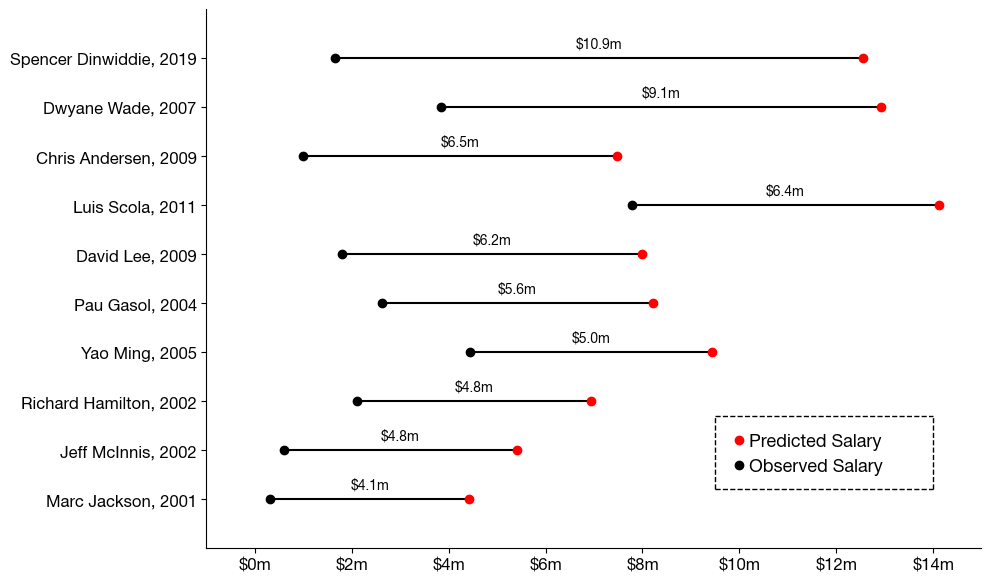

In [43]:
# Format big numbers
pd.options.display.float_format = '{:.2f}'.format

salaries = pd.read_csv('Data01.csv')
salaries = salaries[['pName', 'season', 'cap', 'salary']]

upaid = salaries.loc[top_underpaid.index]
upaid['salary'] = upaid['salary'].astype('int')
upaid['salary_pred'] = pd.Series(top_underpaid['pred'] * upaid['cap']).astype('int')
upaid.drop(columns=['cap'], inplace=True)

# Sort by underpayment estimate
upaid['diff'] = upaid['salary_pred'] - upaid['salary']
upaid = upaid.sort_values(by='diff', ascending=True)

# Dumbbell plot
# Import HelveticaNeue
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

font_dirs = ['fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'Helvetica Neue'
fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(upaid.shape[0])

# Lines and labels
for i in y_pos:
    ax.plot([upaid.iloc[i]['salary_pred'], upaid.iloc[i]['salary']], [i, i], color='black')
    midpoint = (upaid.iloc[i]['salary_pred'] + upaid.iloc[i]['salary']) / 2
    text = f"${upaid.iloc[i]['diff'] / 1_000_000:.1f}m"
    ax.text(midpoint, i+0.3, text, va='center', ha='center', fontsize=10)

# Dots
ax.scatter(upaid['salary_pred'], y_pos, color='red', zorder=2)
ax.scatter(upaid['salary'], y_pos, color='black', zorder=2)

# Legend
ax.scatter(10_000_000, 1.2, color='red')
ax.scatter(10_000_000, 0.7, color='black')
ax.text(10_200_000, 1.17, 'Predicted Salary', va='center', ha='left', fontsize=13)
ax.text(10_200_000, 0.67, 'Observed Salary', va='center', ha='left', fontsize=13)
ax.plot([9_500_000, 14_000_000], [1.7, 1.7], color='black', linewidth=1, linestyle='--')
ax.plot([9_500_000, 14_000_000], [0.2, 0.2], color='black', linewidth=1, linestyle='--')
ax.plot([9_500_000, 9_500_000], [0.2, 1.7], color='black', linewidth=1, linestyle='--')
ax.plot([14_000_000, 14_000_000], [0.2, 1.7], color='black', linewidth=1, linestyle='--')

# Axes
ax.set_ylim(-1, 10)
ax.set_xlim(-1_000_000, 15_000_000)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.0f}m'))
plt.yticks(y_pos, upaid['pName']+', '+upaid['season'].astype('str'))
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

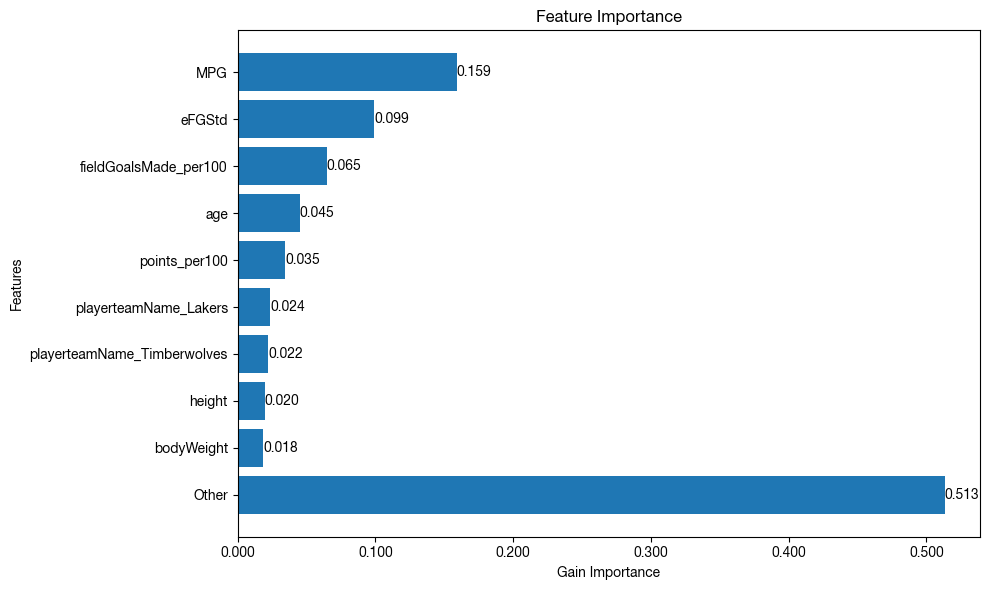

In [14]:
# Feature importances of the chosen model
# XGB Importances
importances = pd.Series(xgb.feature_importances_, index=X_full_test.columns).sort_values(ascending=False)

# Keep only top 9 like in SHAP plot
top9 = importances.head(9)
rest_sum = importances.iloc[9:].sum()
final_importances = pd.concat([top9,pd.Series({'Other': rest_sum})])

plt.figure(figsize=(10, 6))
bars = plt.barh(final_importances.index[::-1], final_importances.values[::-1])
plt.xlabel('Gain Importance')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}')) # X-axis to 3 decimals
plt.ylabel('Features')
plt.title('Feature Importance')
plt.tight_layout()
# Labels next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}',va='center')
plt.show()

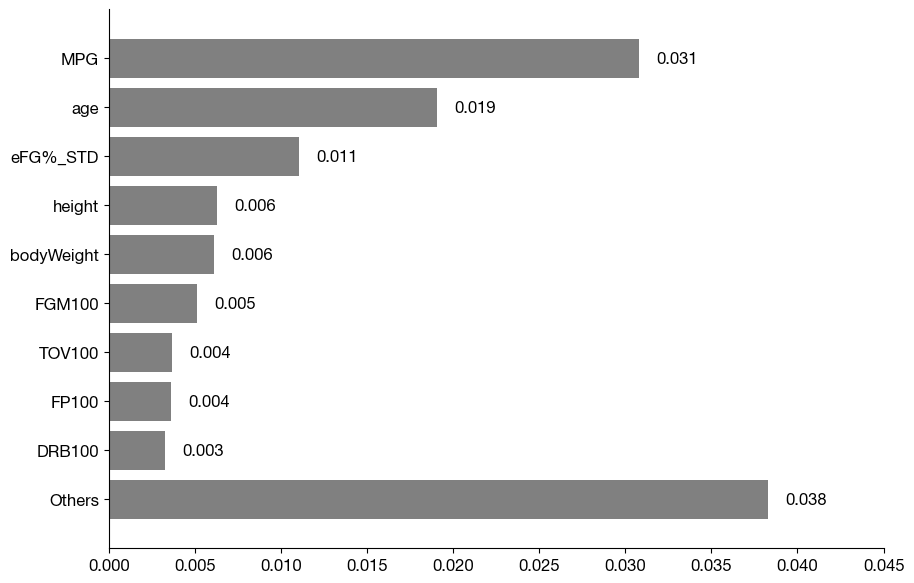

In [14]:
# SHAP values
explainer = shap.Explainer(xgb)
shap_values = explainer(X_full_test)

vals = np.mean(np.abs(shap_values.values), axis=0)
features = shap_values.feature_names

# Into dataset for easier manipulation
shap_data = pd.DataFrame([features, vals]).transpose()
shap_data.columns = ['feature', 'shap']

# Compound non-top 9
shap_data = shap_data.sort_values(by='shap', ascending=False)
top9 = shap_data.iloc[:9]
others_sum = shap_data.iloc[9:]['shap'].sum()
others_row = pd.DataFrame([['Others', others_sum]], columns=['feature', 'shap'])
shap_data = pd.concat([top9, others_row], ignore_index=True)

# Rename
shap_data['feature'] = pd.Series(['MPG', 'age', 'eFG%_STD', 'height', 'bodyWeight', 'FGM100', 'TOV100', 'FP100', 'DRB100', 'Others'])

# Invert for matplotlib
shap_data = shap_data.iloc[::-1]

# Import HelveticaNeue
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

font_dirs = ['fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'Helvetica Neue'
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(shap_data['feature'], shap_data['shap'], color='gray')

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, str(round(width, 3)), va='center', fontsize=12)
    
# Axes
plt.ylim(-1, 10)
plt.xlim(0, 0.045)
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

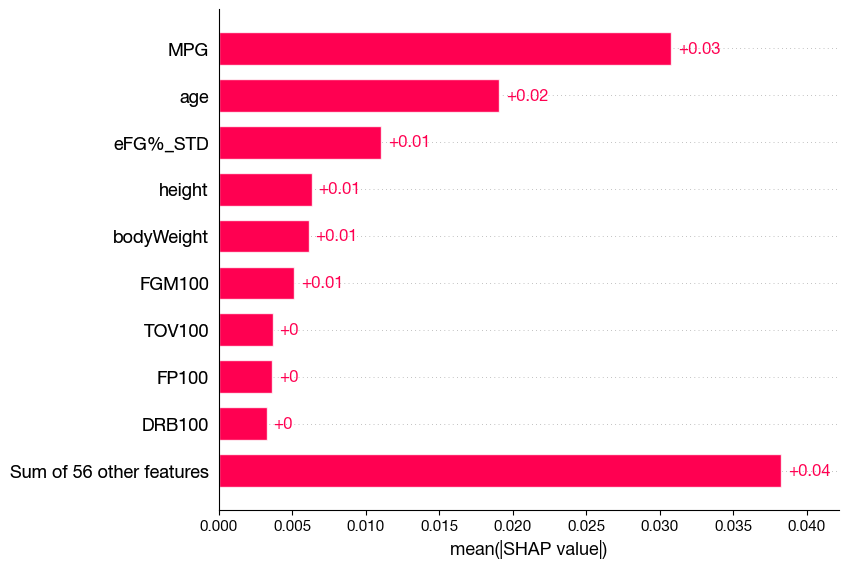

In [28]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

shap.plots.bar(shap_values)
labels = [item.get_text() for item in ax.get_yticklabels()]

plt.show()
#shap.plots.beeswarm(shap_values)